# 6. JODIE benchmark panel

This notebook selects the epoch with the highest validation event AUROC for each dataset, model, and seed (earliest epoch on ties). Every reported test and rollout metric comes from that same checkpoint. Training-only records and nonfinite validation scores are excluded. Duplicate runs use the most recently modified source file.

Results are aggregated by dataset and model across available seeds. Tables and figures report mean \(\pm\) SEM whenever at least two seeds are available. **Use a directory containing a single evaluation protocol: pre-fix and corrected JODIE results must not be pooled.** Saved outputs must be regenerated after changing the selection rule or data.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 8,
    'axes.labelsize': 8, 'axes.titlesize': 9,
    'xtick.labelsize': 7, 'ytick.labelsize': 8,
    'legend.fontsize': 6.8, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 600,
})

ROOT = Path.cwd().resolve()
if not (ROOT / 'derived').exists():
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / 'derived/results/jodie_benchmark_panel'
FIGURE_DIR = ROOT / 'derived/results/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['wikipedia', 'reddit', 'mooc', 'lastfm']
DATASET_LABELS = {'wikipedia': 'Wikipedia', 'reddit': 'Reddit', 'mooc': 'MOOC', 'lastfm': 'LastFM'}
MODEL_ORDER = ['fnn', 'sum/tgn_gru', 'deepsets/tgn_gru', 'settransformer/tgn_gru',
               'hopfield/hopfield_update', 'settransformer/lnn', 'settransformer/hnn']
MODEL_LABELS = {
    'fnn': 'FNN', 'sum/tgn_gru': 'Sum/TGN-GRU', 'deepsets/tgn_gru': 'DeepSets/TGN-GRU',
    'settransformer/tgn_gru': 'SetTransformer/TGN-GRU',
    'hopfield/hopfield_update': 'Hopfield',
    'settransformer/lnn': 'SetTransformer/LNN',
    'settransformer/hnn': 'SetTransformer/HNN',
}
MODEL_COLORS = {
    'fnn': '#0072B2', 'sum/tgn_gru': '#D55E00', 'deepsets/tgn_gru': '#009E73',
    'settransformer/tgn_gru': '#CC79A7', 'hopfield/hopfield_update': '#7F7F7F',
    'settransformer/lnn': '#E69F00', 'settransformer/hnn': '#56B4E9',
}


In [2]:
def terminal_records(path: Path) -> dict[str, dict]:
    """Select highest finite validation AUROC per model; earliest epoch breaks ties."""
    terminal = {}
    with path.open() as handle:
        for line in handle:
            if not line.strip():
                continue
            try:
                row = json.loads(line)
                auc = float(row.get('val', {}).get('event_auroc', float('nan')))
            except (ValueError, TypeError):
                continue
            if not np.isfinite(auc):
                continue
            old = terminal.get(row['run'])
            if old is None or (auc, -row['epoch']) > (float(old['val']['event_auroc']), -old['epoch']):
                terminal[row['run']] = row
    return terminal

candidates = []
for path in sorted(RESULTS_DIR.glob('jodie_*.jsonl')):
    match = re.match(r'jodie_(wikipedia|reddit|mooc|lastfm)_seed(\d+)_', path.name)
    if match is None:
        continue
    dataset, seed = match.group(1), int(match.group(2))
    for run, record in terminal_records(path).items():
        candidates.append({
            'dataset': dataset, 'seed': seed, 'run': run, 'epoch': int(record['epoch']),
            'source_file': path.name, 'modified': path.stat().st_mtime, 'record': record,
        })

candidate_table = pd.DataFrame(candidates)
if candidate_table.empty:
    raise FileNotFoundError(f'No JODIE JSONL files found in {RESULTS_DIR}')

# Prefer the latest source file for duplicate runs, not a higher selected epoch.
# Keep corrected and pre-fix protocols in separate result directories.
selected = (candidate_table.sort_values(['dataset', 'seed', 'run', 'modified', 'source_file'])
    .drop_duplicates(['dataset', 'seed', 'run'], keep='last')
    .sort_values(['dataset', 'seed', 'run']))
ignored = candidate_table.loc[~candidate_table.index.isin(selected.index)]

coverage = (selected.assign(model=selected.run.map(MODEL_LABELS))
    .pivot_table(index='dataset', columns='model', values='epoch', aggfunc='max')
    .reindex(index=DATASETS, columns=[MODEL_LABELS[m] for m in MODEL_ORDER]))
print(f'Selected {len(selected)} best-validation-AUROC checkpoints; ignored {len(ignored)} superseded restart record(s).')
print('Entries are selected epoch numbers. All test metrics use that same checkpoint.')
display(coverage)


Selected 26 terminal model records; ignored 1 superseded restart record(s).
Entries are terminal epoch numbers; blank entries are not yet available.


model,FNN,Sum/TGN-GRU,DeepSets/TGN-GRU,SetTransformer/TGN-GRU,Hopfield,SetTransformer/LNN,SetTransformer/HNN
dataset,,,,,,,
wikipedia,140.0,20.0,30.0,30.0,1.0,NaN,NaN
reddit,140.0,30.0,30.0,20.0,20.0,50.0,40.0
mooc,140.0,20.0,50.0,40.0,40.0,30.0,30.0
lastfm,140.0,40.0,40.0,20.0,30.0,20.0,20.0


In [3]:
summary_rows = []
for item in selected.itertuples(index=False):
    row = item.record
    test = row.get('test', {})
    rollout = row.get('rollout_test', {})
    summary_rows.append({
        'dataset': item.dataset, 'seed': item.seed, 'run': item.run,
        'model': MODEL_LABELS.get(item.run, item.run), 'epoch': item.epoch,
        'source_file': item.source_file,
        'mrr': test.get('mrr'), 'event_auroc': test.get('event_auroc'),
        'event_auprc': test.get('event_auprc'),
        'rollout_horizon': rollout.get('rollout_horizon'),
        'rollout_mrr': rollout.get('rollout_mrr'),
        'rollout_event_auroc': rollout.get('rollout_event_auroc'),
        'rollout_event_auprc': rollout.get('rollout_event_auprc'),
    })
results = pd.DataFrame(summary_rows)
for column in ['mrr', 'event_auroc', 'event_auprc', 'rollout_horizon', 'rollout_mrr', 'rollout_event_auroc', 'rollout_event_auprc']:
    results[column] = pd.to_numeric(results[column], errors='coerce')

METRICS = {'mrr': 'MRR', 'event_auroc': 'AUC', 'event_auprc': 'AUPR'}

def mean_sem(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    grouped = frame.groupby(['dataset', 'run'])[columns].agg(['mean', 'std', 'count'])
    for column in columns:
        grouped[(column, 'sem')] = grouped[(column, 'std')].fillna(0.0) / np.sqrt(grouped[(column, 'count')])
    return grouped

aggregate = mean_sem(results, list(METRICS))
full_table = aggregate.reindex(pd.MultiIndex.from_product([DATASETS, MODEL_ORDER], names=['Dataset', 'Model']))
full_table.index = pd.MultiIndex.from_tuples(
    [(DATASET_LABELS[dataset], MODEL_LABELS[model]) for dataset, model in full_table.index],
    names=['Dataset', 'Model'])
display(full_table.round(4))


mrr  event_auroc  event_auprc
Dataset   Model                                                   
Wikipedia FNN                     0.8785       0.9453       0.9530
          Sum/TGN-GRU             0.8000       0.5258       0.6761
          DeepSets/TGN-GRU        0.8270       0.6493       0.7570
          SetTransformer/TGN-GRU  0.8000       0.7113       0.8122
          Hopfield                   NaN          NaN          NaN
          SetTransformer/LNN         NaN          NaN          NaN
          SetTransformer/HNN         NaN          NaN          NaN
Reddit    FNN                     0.9568       0.9882       0.9874
          Sum/TGN-GRU             0.9428       0.9646       0.9729
          DeepSets/TGN-GRU        0.9444       0.9836       0.9846
          SetTransformer/TGN-GRU  0.7919       0.8385       0.8931
          Hopfield                0.9109       0.9682       0.9685
          SetTransformer/LNN      0.6273       0.7211       0.7576
          SetTransformer/HNN      0.8939       0.9599       0.9661
MOOC      FNN                     0.9479       0.9932       0.9877
          Sum/TGN-GRU             0.9622       0.9925       0.9860
          DeepSets/TGN-GRU        0.9718       0.9933       0.9882
          SetTransformer/TGN-GRU  0.9787       0.9952       0.9929
          Hopfield                0.9675       0.9899       0.9832
          SetTransformer/LNN      0.8873       0.5127       0.5213
          SetTransformer/HNN      0.1584       0.5062       0.5094
LastFM    FNN                     0.4931       0.8242       0.7859
          Sum/TGN-GRU             0.5603       0.4858       0.6228
          DeepSets/TGN-GRU        0.4961       0.3959       0.5563
          SetTransformer/TGN-GRU  0.1597       0.5084       0.6277
          Hopfield                0.1411       0.5000       0.5000
          SetTransformer/LNN      0.2766       0.5149       0.5520
          SetTransformer/HNN      0.2833       0.5195       0.5578

In [4]:
# Compact, paper-facing table: FNN next-event prediction versus the strongest available baseline.
def format_stat(row: pd.Series, metric: str) -> str:
    count = row[(metric, 'count')]
    if pd.isna(count) or count == 0:
        return '--'
    if count == 1:
        return f"{row[(metric, 'mean')]:.3f} (n=1)"
    return f"{row[(metric, 'mean')]:.3f} $\pm$ {row[(metric, 'sem')]:.3f}"

headline_rows = []
for dataset in DATASETS:
    subset = aggregate.loc[dataset]
    fnn = subset.loc['fnn'] if 'fnn' in subset.index else None
    row = {'Dataset': DATASET_LABELS[dataset]}
    for metric, label in METRICS.items():
        baseline = subset.drop(index='fnn', errors='ignore').dropna(subset=[(metric, 'mean')])
        best = baseline.loc[baseline[(metric, 'mean')].idxmax()] if not baseline.empty else None
        row[f'FNN {label}'] = format_stat(fnn, metric) if fnn is not None else '--'
        row[f'Best baseline {label}'] = format_stat(best, metric) if best is not None else '--'
        row[f'Baseline for {label}'] = MODEL_LABELS[best.name] if best is not None else '---'
    headline_rows.append(row)
headline = pd.DataFrame(headline_rows).set_index('Dataset')
display(headline)

latex_columns = ['Dataset', 'FNN MRR', 'Best baseline MRR', 'FNN AUC', 'Best baseline AUC', 'FNN AUPR', 'Best baseline AUPR']
latex_table = headline.reset_index()[latex_columns]
print(latex_table.to_latex(index=False, escape=False))


,FNN MRR,Best baseline MRR,Baseline for MRR,FNN $\Delta$ MRR,FNN AUC,Best baseline AUC,Baseline for AUC,FNN $\Delta$ AUC,FNN AUPR,Best baseline AUPR,Baseline for AUPR,FNN $\Delta$ AUPR
Dataset,,,,,,,,,,,,
Wikipedia,0.8785,0.8270,DeepSets/TGN-GRU,0.0515,0.9453,0.7113,SetTransformer/TGN-GRU,0.2340,0.9530,0.8122,SetTransformer/TGN-GRU,0.1408
Reddit,0.9568,0.9444,DeepSets/TGN-GRU,0.0124,0.9882,0.9836,DeepSets/TGN-GRU,0.0046,0.9874,0.9846,DeepSets/TGN-GRU,0.0028
MOOC,0.9479,0.9787,SetTransformer/TGN-GRU,-0.0308,0.9932,0.9952,SetTransformer/TGN-GRU,-0.0020,0.9877,0.9929,SetTransformer/TGN-GRU,-0.0053
LastFM,0.4931,0.5603,Sum/TGN-GRU,-0.0672,0.8242,0.5195,SetTransformer/HNN,0.3047,0.7859,0.6277,SetTransformer/TGN-GRU,0.1583


\begin{tabular}{lllllll}
\toprule
Dataset & FNN MRR & Best baseline MRR & FNN AUC & Best baseline AUC & FNN AUPR & Best baseline AUPR \\
\midrule
Wikipedia & 0.878 & 0.827 & 0.945 & 0.711 & 0.953 & 0.812 \\
Reddit & 0.957 & 0.944 & 0.988 & 0.984 & 0.987 & 0.985 \\
MOOC & 0.948 & 0.979 & 0.993 & 0.995 & 0.988 & 0.993 \\
LastFM & 0.493 & 0.560 & 0.824 & 0.520 & 0.786 & 0.628 \\
\bottomrule
\end{tabular}



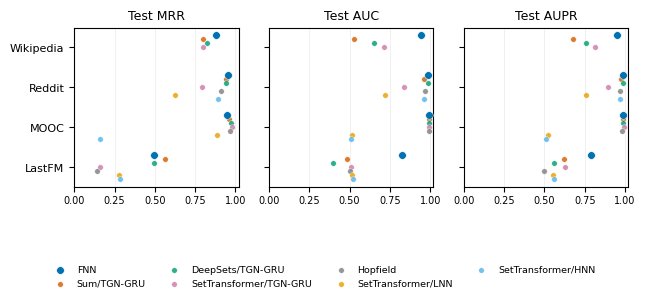

/home/tweninge/projects/ift/derived/results/figures/jodie_benchmark_test_panel.pdf


In [5]:
plot_metrics = [('mrr', 'Test MRR'), ('event_auroc', 'Test AUC'), ('event_auprc', 'Test AUPR')]
fig, axes = plt.subplots(1, 3, figsize=(6.5, 2.45), sharey=True)
y_base = np.arange(len(DATASETS))
offsets = np.linspace(-.30, .30, len(MODEL_ORDER))
for ax, (metric, title) in zip(axes, plot_metrics):
    for offset, model in zip(offsets, MODEL_ORDER):
        values = aggregate.reindex(pd.MultiIndex.from_product([DATASETS, [model]], names=['dataset', 'run']))
        mean = values[(metric, 'mean')].to_numpy()
        sem = values[(metric, 'sem')].to_numpy()
        ax.errorbar(mean, y_base + offset, xerr=sem, fmt='o', markersize=5 if model == 'fnn' else 3.8,
                    color=MODEL_COLORS[model], markeredgecolor='white', markeredgewidth=.35,
                    capsize=1.8, linestyle='none', alpha=1.0 if model == 'fnn' else .82,
                    zorder=3 if model == 'fnn' else 2, label=MODEL_LABELS[model])
    ax.set_title(title)
    ax.set_xlim(0, 1.02)
    ax.set_xticks([0, .25, .5, .75, 1.0])
    ax.grid(axis='x', alpha=.24, linewidth=.55)
    ax.set_yticks(y_base, [DATASET_LABELS[d] for d in DATASETS])
axes[0].invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc='lower center', bbox_to_anchor=(.5, -.22), frameon=False)
fig.tight_layout(rect=(0, .10, 1, 1))
panel_path = FIGURE_DIR / 'jodie_benchmark_test_panel.pdf'
fig.savefig(panel_path, bbox_inches='tight')
plt.show()
print(panel_path)


In [6]:
# FNN-only scheduled-query rollout diagnostic. This is not an event-schedule-generation claim.
rollout_columns = ['rollout_horizon', 'mrr', 'event_auroc', 'event_auprc', 'rollout_mrr', 'rollout_event_auroc', 'rollout_event_auprc']
fnn_rollout = results.loc[results.run == 'fnn', ['dataset', *rollout_columns]]
fnn_rollout = fnn_rollout.groupby('dataset')[rollout_columns].agg(['mean', 'std', 'count'])
for column in rollout_columns:
    fnn_rollout[(column, 'sem')] = fnn_rollout[(column, 'std')].fillna(0.0) / np.sqrt(fnn_rollout[(column, 'count')])
fnn_rollout = fnn_rollout.reindex(DATASETS)
fnn_rollout.index = [DATASET_LABELS[d] for d in DATASETS]
display(fnn_rollout.round(4))

print('Rollout records retain the future pair-query schedule; interpret these as closed-loop state-propagation diagnostics, not fully generative social-event forecasts.')


,Horizon,Test MRR,Test AUC,Test AUPR,Rollout MRR,Rollout AUC,Rollout AUPR
Wikipedia,20.0,0.8785,0.9453,0.9530,0.8798,0.9477,0.9540
Reddit,20.0,0.9568,0.9882,0.9874,0.9591,0.9897,0.9886
MOOC,20.0,0.9479,0.9932,0.9877,0.9493,0.9936,0.9880
LastFM,20.0,0.4931,0.8242,0.7859,0.4935,0.8196,0.7627


Rollout records retain the future pair-query schedule; interpret these as closed-loop state-propagation diagnostics, not fully generative social-event forecasts.


### Recommended paper artifacts

Use the compact FNN-versus-best-baseline table in the main paper only after all intended panel runs are available. Keep the complete model table and the score panel in the appendix. With multi-seed repetitions, replace point estimates with mean \(\pm\) SEM and retain the same table structure.